# Topical Diversity Analysis

Explores whether geographic diversity correlates with topical diversity across ICSA/WICSA/ECSA and ICSE (2010–2025).

**Research question:** Do papers from underrepresented regions cover different research topics than papers from dominant regions?

## Imports & config

In [35]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
from scipy.stats import pearsonr, spearmanr

INPUT_FILE_ICSA = Path("../../data/clean/icsa_with_regions.json")
INPUT_FILE_ICSE = Path("../../data/clean/icse_with_regions.json")
OUTPUT_DIR      = Path("figures/topics")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# number of top topics to show in charts — reduce if too cluttered
TOP_N_TOPICS = 15

REGION_COLORS = {
    "W. Europe":            "#3266ad",
    "North America":        "#e07b3a",
    "Asia-Pacific":         "#3aa66b",
    "E. Europe":            "#7b52ab",
    "Latin America":        "#b04db0",
    "Middle East & Africa": "#c0474a",
    "Other":                "#888780",
}

def style_ax(ax, years=None):
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xlabel("Year", labelpad=6)
    if years is not None:
        ax.set_xticks(years)

def save_fig(fig, name):
    fig.savefig(OUTPUT_DIR / name, dpi=150, bbox_inches="tight")
    print(f"Saved → {name}")

## Load & inspect data

In [36]:
def load(path):
    with open(path) as f:
        df = pd.DataFrame(json.load(f))
    df["region"] = df["region"].fillna("Other")
    return df

df_icsa = load(INPUT_FILE_ICSA)
df_icse = load(INPUT_FILE_ICSE)

for label, df in [("ICSA", df_icsa), ("ICSE", df_icse)]:
    print(f"\n=== {label} ===")
    print(f"  Total rows:       {len(df):,}")
    print(f"  Unique DOIs:      {df['doi'].nunique():,}")
    print(f"  Has primary_topic: {df['primary_topic'].notna().sum():,} rows "
          f"({df['primary_topic'].notna().mean()*100:.1f}%)")
    print(f"  Unique topics:    {df['primary_topic'].nunique()}")
    print(f"  Top 10 topics:")
    print(df['primary_topic'].value_counts().head(10).to_string())

Task was destroyed but it is pending!
task: <Task pending name='Task-206' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/ronaliuzhong/Desktop/softwaredev2/geo_data/venv/lib/python3.13/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-207' coro=<Kernel.shell_main() running at /Users/ronaliuzhong/Desktop/softwaredev2/geo_data/venv/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/ronaliuzhong/Desktop/softwaredev2/geo_data/venv/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py:563]>
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/json/decoder.py:361: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  obj, end = self.scan_once(s, idx)
Task was destroyed but it is pending!
task: <Task pending name='Task-207' coro=<Kernel.shell_main() running at /Users/ronaliuzhong/Desktop/softwaredev2/geo_data/venv/lib/python3.13/


=== ICSA ===
  Total rows:       1,943
  Unique DOIs:      479
  Has primary_topic: 1,943 rows (100.0%)
  Unique topics:    73
  Top 10 topics:
primary_topic
Advanced Software Engineering Methodologies        494
Software Engineering Research                      324
Software System Performance and Reliability        300
Service-Oriented Architecture and Web Services      84
Blockchain Technology Applications and Security     79
Software Engineering Techniques and Practices       55
IoT and Edge/Fog Computing                          36
Semantic Web and Ontologies                         32
Cloud Computing and Resource Management             27
Security and Verification in Computing              24

=== ICSE ===
  Total rows:       13,030
  Unique DOIs:      2,900
  Has primary_topic: 13,030 rows (100.0%)
  Unique topics:    203
  Top 10 topics:
primary_topic
Software Engineering Research                     3999
Software Testing and Debugging Techniques         2075
Advanced Malware 

## Deduplicate

Use one row per `(doi, primary_topic, region)` — this counts each topic once per paper per region, avoiding inflation from papers with many authors.

In [37]:
def dedupe_topics(df):
    """One row per (doi, primary_topic, region). Drops rows with no topic."""
    return (
        df.dropna(subset=["primary_topic"])
          .drop_duplicates(subset=["doi", "primary_topic", "region"])
          .copy()
    )

dt_icsa = dedupe_topics(df_icsa)
dt_icse = dedupe_topics(df_icse)

print(f"ICSA after dedup: {len(dt_icsa):,} rows | {dt_icsa['doi'].nunique():,} unique papers")
print(f"ICSE after dedup: {len(dt_icse):,} rows | {dt_icse['doi'].nunique():,} unique papers")

ICSA after dedup: 592 rows | 479 unique papers
ICSE after dedup: 3,953 rows | 2,900 unique papers


## Region × topic matrix

In [38]:
def region_topic_matrix(dt):
    """Returns raw counts and percentage share per region."""
    matrix = (
        dt.groupby(["region", "primary_topic"])
          .size()
          .unstack(fill_value=0)
    )
    pct = matrix.div(matrix.sum(axis=1), axis=0) * 100
    return matrix, pct

mat_icsa, pct_icsa = region_topic_matrix(dt_icsa)
mat_icse, pct_icse = region_topic_matrix(dt_icse)

print("ICSA region × topic (counts):")
print(mat_icsa.to_string())

ICSA region × topic (counts):
primary_topic  Access Control and Trust  Advanced Data Storage Technologies  Advanced Database Systems and Queries  Advanced Malware Detection Techniques  Advanced Software Engineering Methodologies  Agricultural risk and resilience  Architecture and Computational Design  Artificial Intelligence in Games  Autonomous Vehicle Technology and Safety  BIM and Construction Integration  Blockchain Technology Applications and Security  Business Process Modeling and Analysis  Cloud Computing and Resource Management  Cloud Data Security Solutions  Complex Systems and Decision Making  Context-Aware Activity Recognition Systems  Data Quality and Management  Data Visualization and Analytics  Dengue and Mosquito Control Research  Design Education and Practice  Digital Transformation in Industry  Digital and Cyber Forensics  Distributed and Parallel Computing Systems  Distributed systems and fault tolerance  Economic Growth and Productivity  Education, Psychology, and So

## Topical diversity per region

Shannon H applied to topics instead of countries.

ICSA topical diversity (Shannon H) by region:
region
W. Europe        2.856758
Other            2.628740
Asia-Pacific     2.331348
North America    2.279761
Latin America    1.742284
E. Europe        1.270018
Africa           1.168282
Middle East      1.004242
dtype: float64

ICSE topical diversity (Shannon H) by region:
region
W. Europe        3.022059
Other            2.990346
North America    2.895265
Asia-Pacific     2.878817
Middle East      2.405624
Latin America    2.300483
E. Europe        2.289952
Africa           2.067976
dtype: float64
Saved → fig_topic_diversity_by_region.png


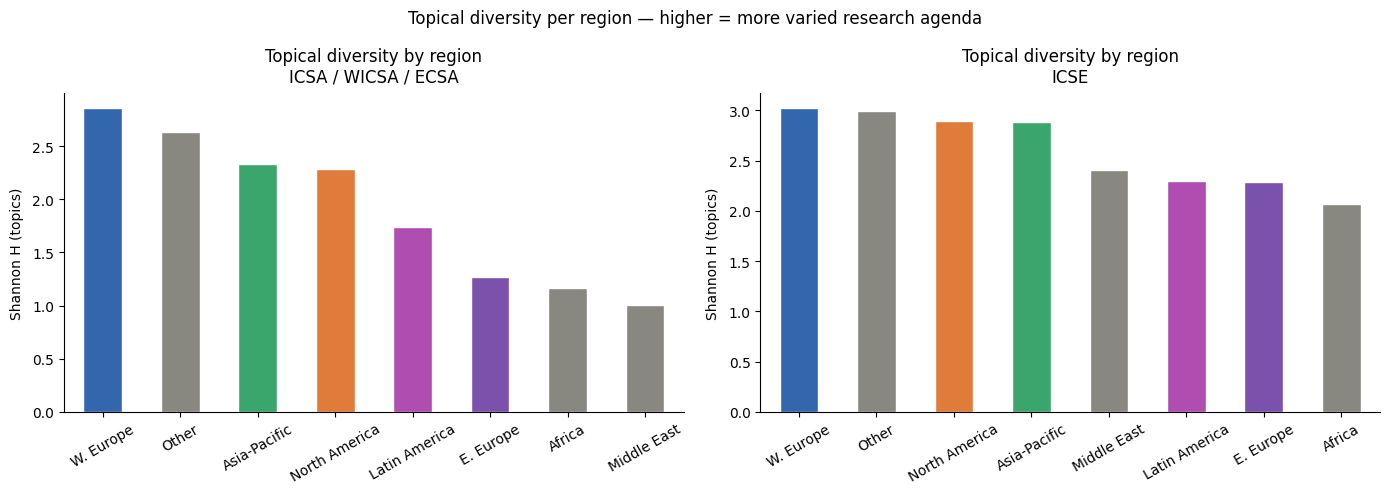

In [39]:
def topic_shannon(row):
    """Shannon H for a row of topic counts."""
    p = row[row > 0] / row[row > 0].sum()
    return float(-(p * np.log(p)).sum())

topic_div_icsa = mat_icsa.apply(topic_shannon, axis=1).sort_values(ascending=False)
topic_div_icse = mat_icse.apply(topic_shannon, axis=1).sort_values(ascending=False)

print("ICSA topical diversity (Shannon H) by region:")
print(topic_div_icsa)
print("\nICSE topical diversity (Shannon H) by region:")
print(topic_div_icse)

# plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
for ax, div, label in zip(axes, [topic_div_icsa, topic_div_icse], ["ICSA / WICSA / ECSA", "ICSE"]):
    colors = [REGION_COLORS.get(r, "#888780") for r in div.index]
    div.plot(kind="bar", ax=ax, color=colors, edgecolor="white")
    ax.set_ylabel("Shannon H (topics)", labelpad=6)
    ax.set_title(f"Topical diversity by region\n{label}", pad=8)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Topical diversity per region — higher = more varied research agenda", fontsize=12)
plt.tight_layout()
save_fig(fig, "fig_topic_diversity_by_region.png")
plt.show()

## Topic × region heatmap

Saved → fig_topic_heatmap_icsa.png


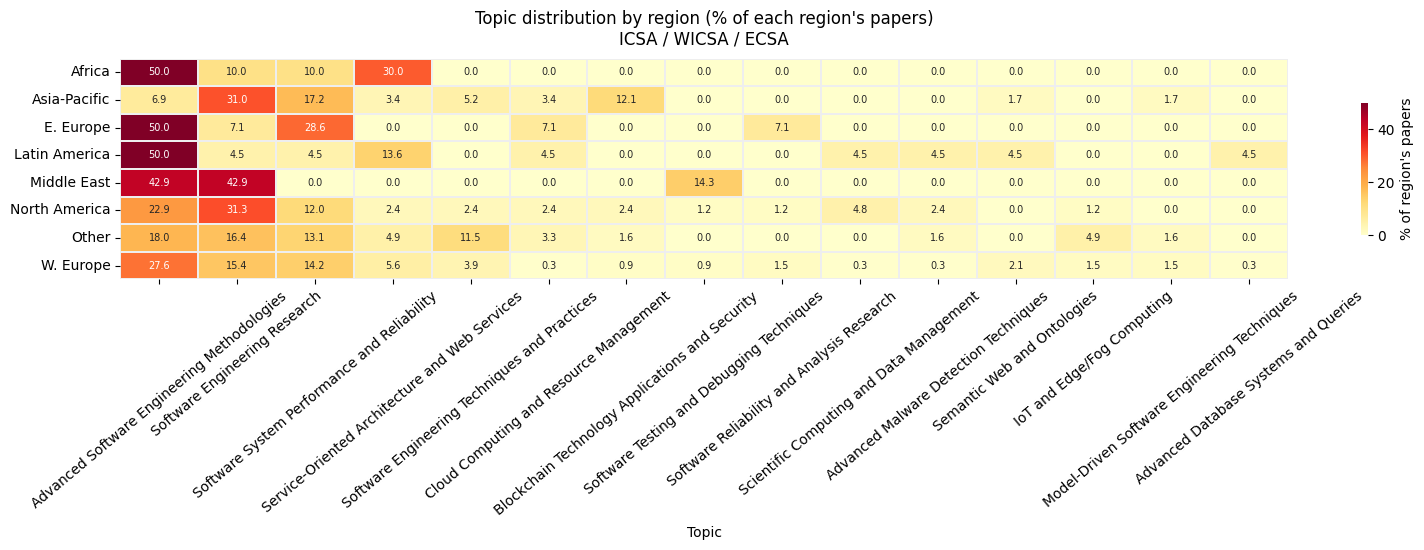

Saved → fig_topic_heatmap_icse.png


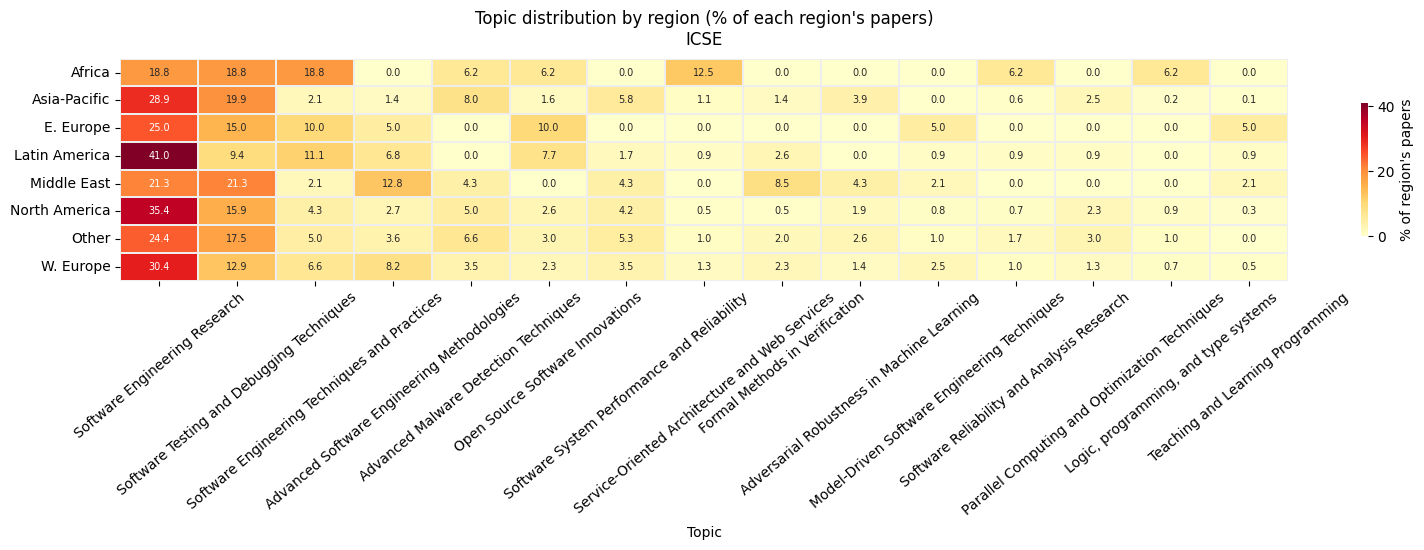

In [40]:
def plot_topic_heatmap(pct, label, filename):
    # keep only top N topics by total frequency
    top_topics = pct.sum().sort_values(ascending=False).head(TOP_N_TOPICS).index
    heat = pct[top_topics]

    fig, ax = plt.subplots(figsize=(16, max(4, len(heat) * 0.7)))
    sns.heatmap(
        heat, ax=ax, cmap="YlOrRd",
        annot=True, fmt=".1f", annot_kws={"size": 7},
        linewidths=0.3, linecolor="#eee",
        cbar_kws={"label": "% of region's papers", "shrink": 0.6}
    )
    ax.set_xlabel("Topic", labelpad=6)
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=40)
    ax.set_title(f"Topic distribution by region (% of each region's papers)\n{label}", pad=10)
    plt.tight_layout()
    save_fig(fig, filename)
    plt.show()

plot_topic_heatmap(pct_icsa, "ICSA / WICSA / ECSA", "fig_topic_heatmap_icsa.png")
plot_topic_heatmap(pct_icse, "ICSE",                 "fig_topic_heatmap_icse.png")

## Topic trends over time per region

Does Asia-Pacific bring different topics as it grows?

Saved → fig_topic_trends_icsa.png


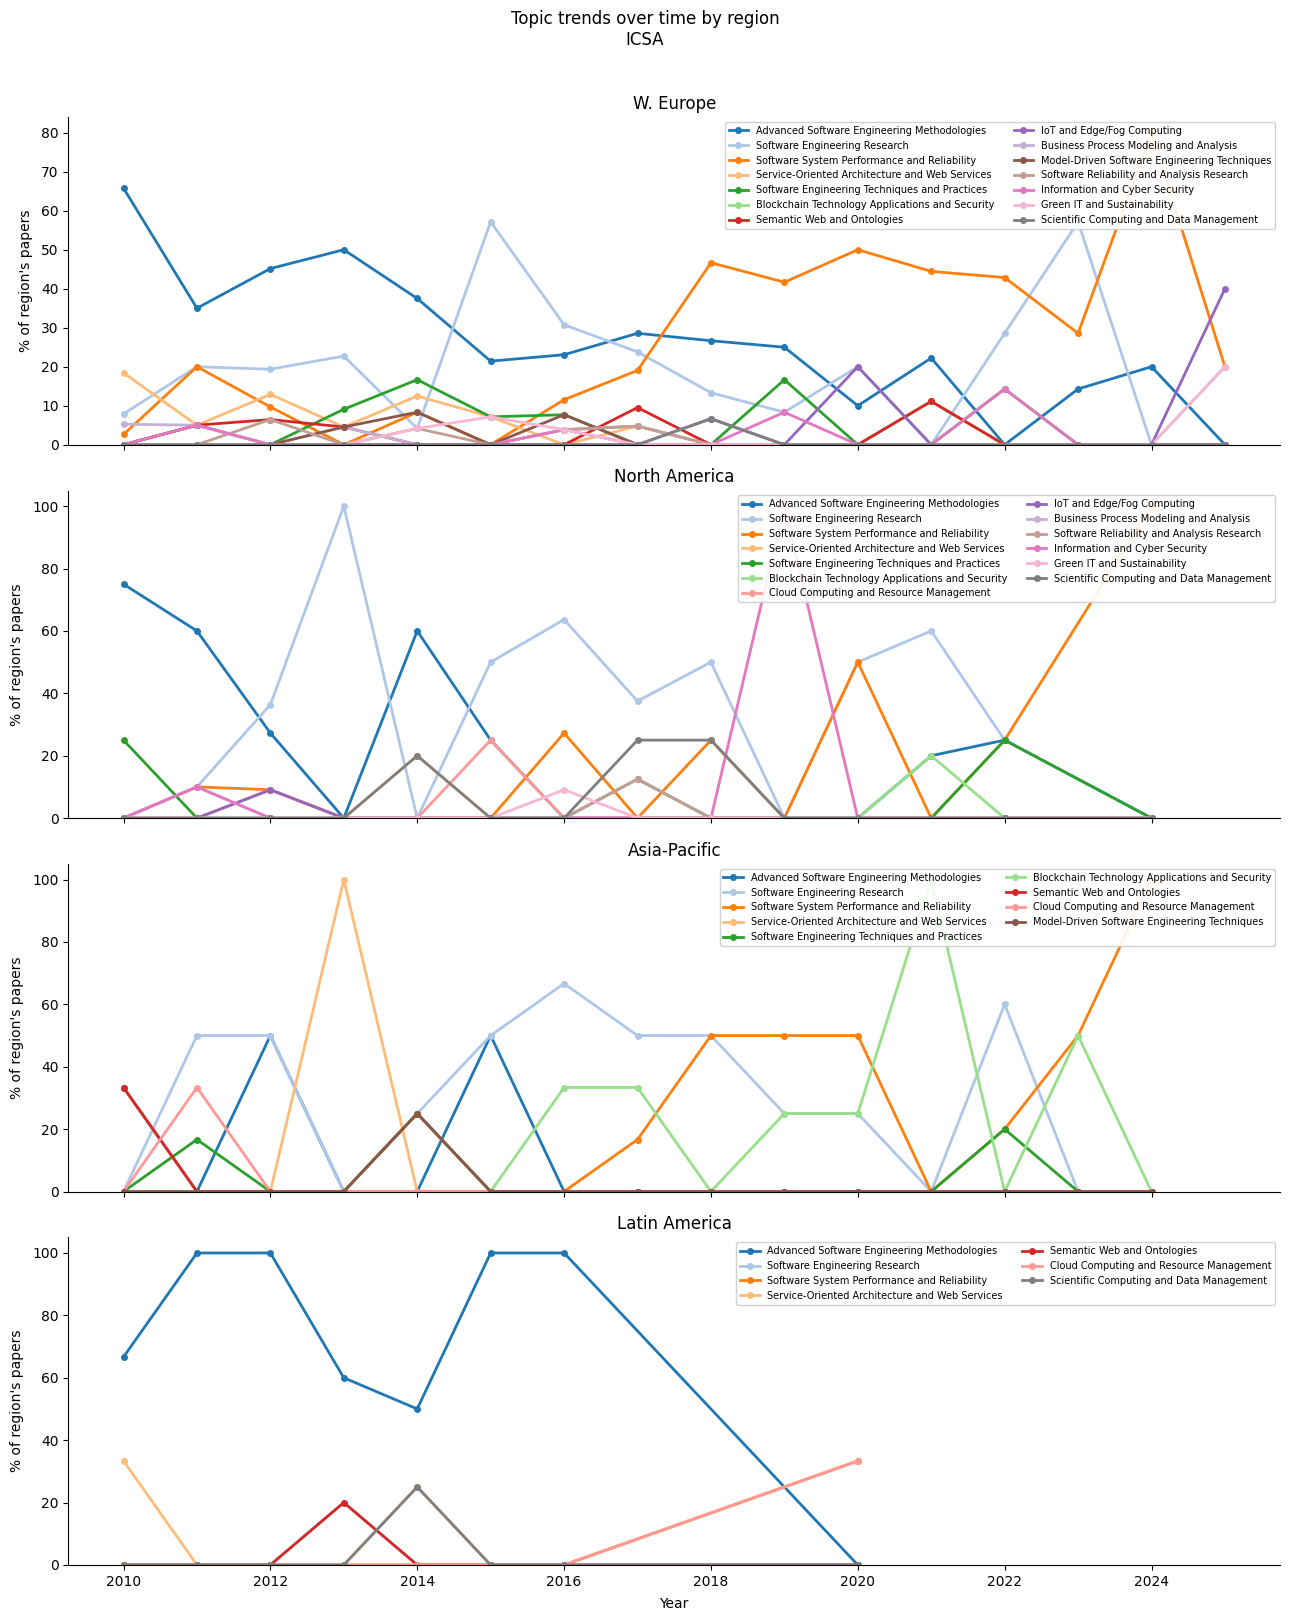

Saved → fig_topic_trends_icse.png


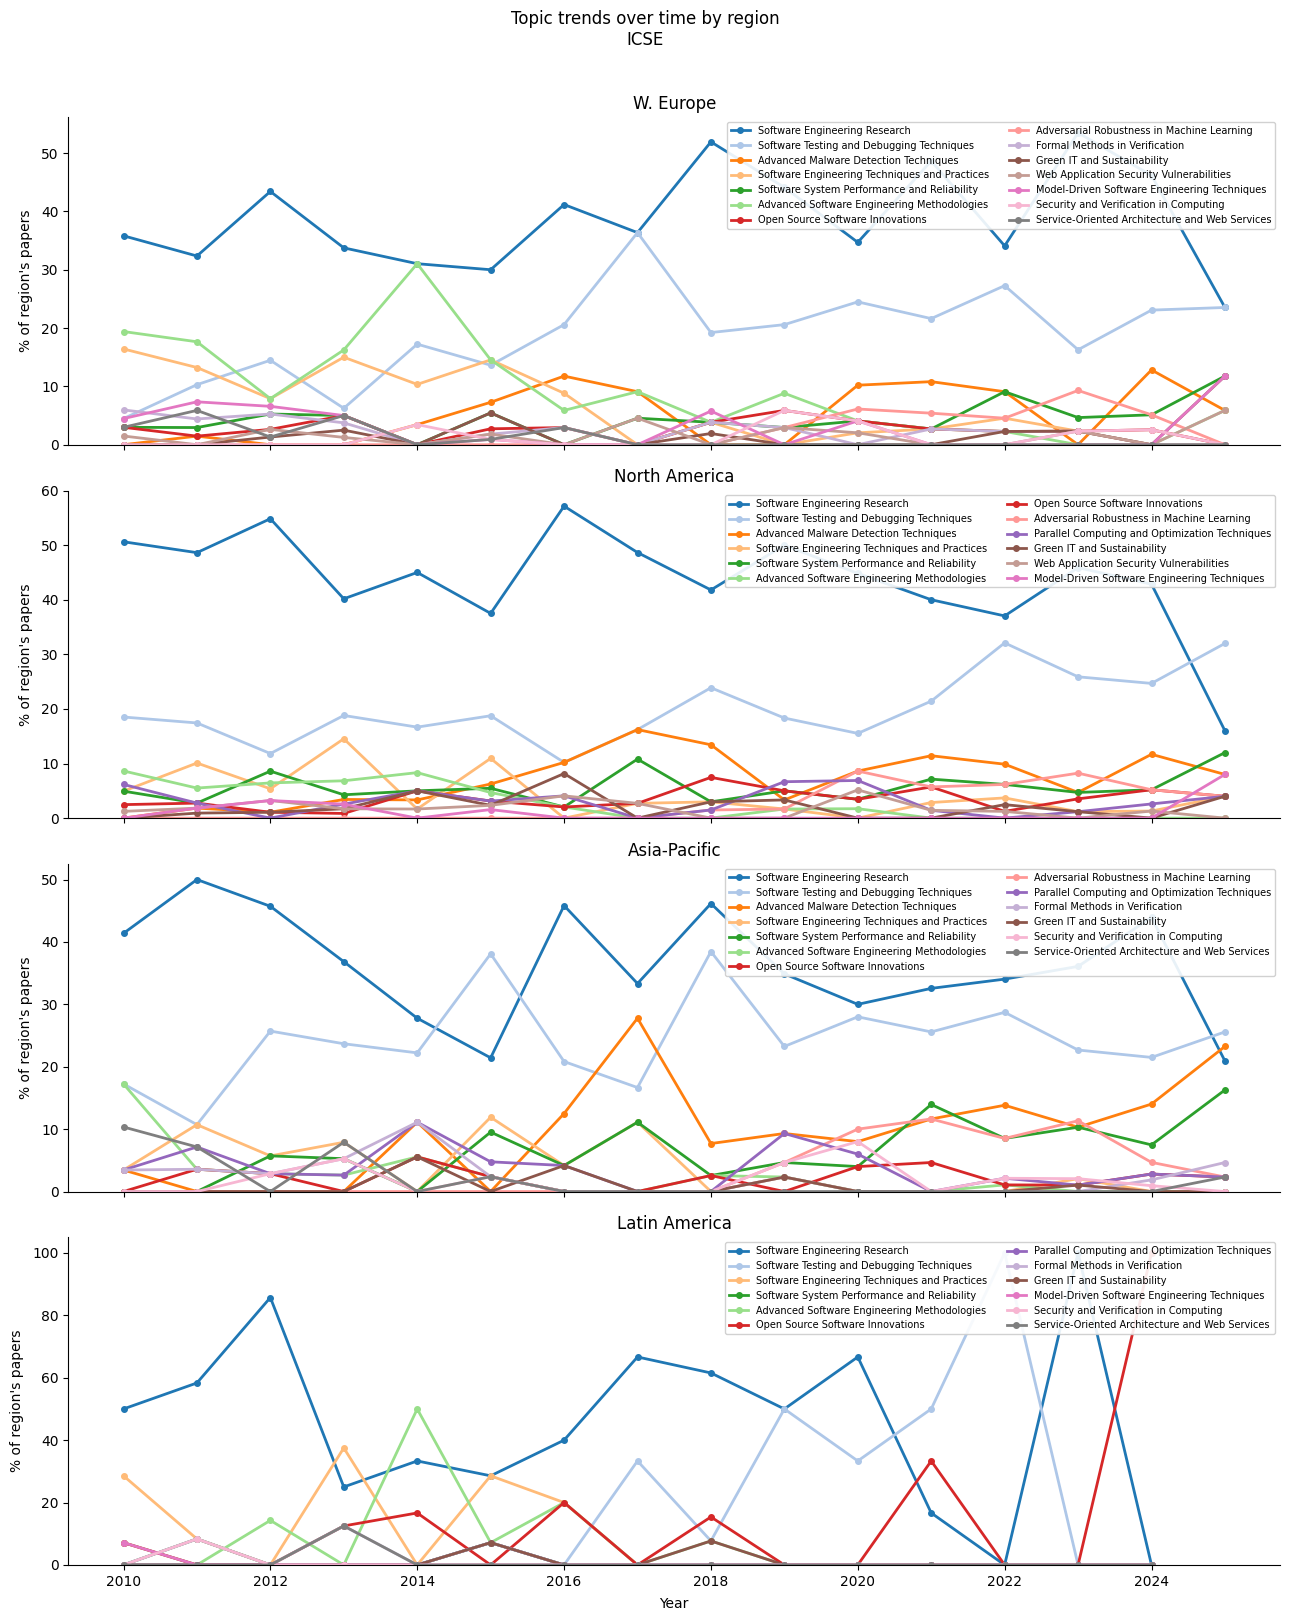

In [41]:
def plot_topic_trends(dt, regions, label, filename):
    top_topics = dt["primary_topic"].value_counts().head(TOP_N_TOPICS).index
    palette    = plt.get_cmap("tab20").colors

    fig, axes = plt.subplots(len(regions), 1,
                             figsize=(13, 4 * len(regions)), sharex=True)
    if len(regions) == 1:
        axes = [axes]

    for ax, region in zip(axes, regions):
        df_r = dt[dt["region"] == region]
        if len(df_r) == 0:
            ax.set_title(f"{region} — no data")
            continue

        year_topic = (
            df_r.groupby(["year", "primary_topic"]).size()
              .unstack(fill_value=0)
              .reindex(columns=top_topics, fill_value=0)
        )
        year_topic_pct = year_topic.div(year_topic.sum(axis=1).replace(0, np.nan), axis=0) * 100

        for i, topic in enumerate(top_topics):
            if topic not in year_topic_pct.columns:
                continue
            if year_topic_pct[topic].max() < 5:
                continue
            ax.plot(year_topic_pct.index, year_topic_pct[topic],
                    "o-", lw=2, ms=4, color=palette[i % len(palette)], label=topic)

        ax.set_ylabel("% of region's papers", labelpad=6)
        ax.set_title(f"{region}", pad=6)
        ax.set_ylim(bottom=0)
        ax.legend(fontsize=7, ncol=2, loc="upper right", framealpha=0.9)
        ax.spines[["top", "right"]].set_visible(False)

    axes[-1].set_xlabel("Year", labelpad=6)
    fig.suptitle(f"Topic trends over time by region\n{label}", fontsize=12, y=1.01)
    plt.tight_layout()
    save_fig(fig, filename)
    plt.show()

regions_to_plot = ["W. Europe", "North America", "Asia-Pacific", "Latin America"]

plot_topic_trends(dt_icsa,
                  [r for r in regions_to_plot if r in dt_icsa["region"].unique()],
                  "ICSA",
                  "fig_topic_trends_icsa.png")

plot_topic_trends(dt_icse,
                  [r for r in regions_to_plot if r in dt_icse["region"].unique()],
                  "ICSE",
                  "fig_topic_trends_icse.png")

## Geographic diversity vs topical diversity

Does a more geographically diverse year also produce more topically diverse research?

Saved → fig_geo_vs_topic_correlation.png


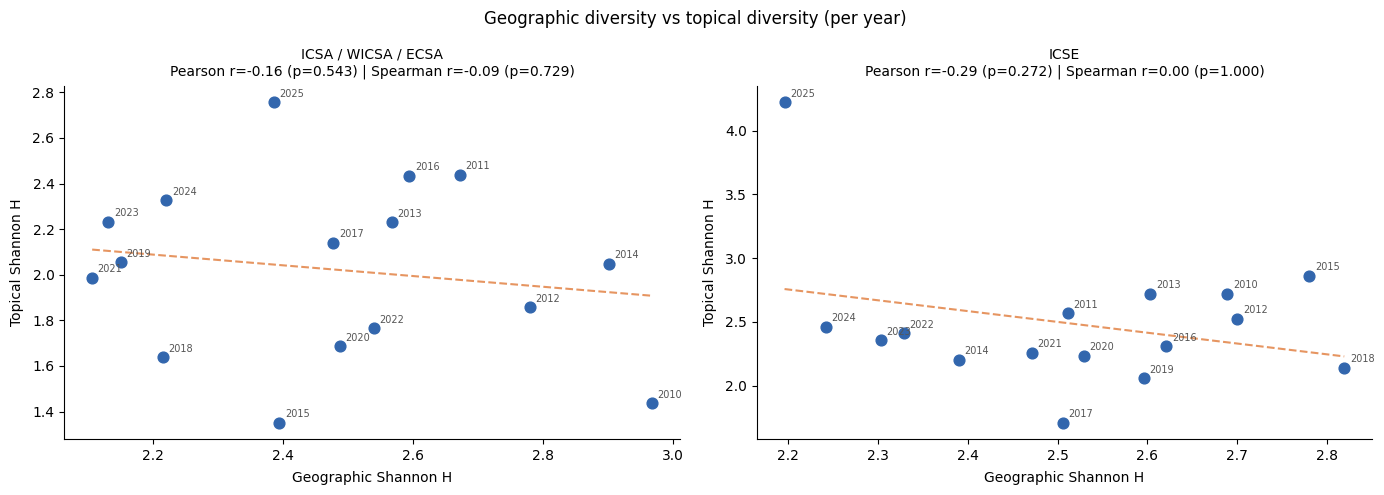

In [42]:
def geo_shannon(df):
    """Geographic Shannon H per year from the full dataframe."""
    rows = []
    for year, g in df.dropna(subset=["country_code"]).drop_duplicates(
            subset=["doi","year","country_code"]).groupby("year"):
        cc = g.groupby("country_code")["doi"].nunique()
        p  = cc / cc.sum()
        H  = float(-(p * np.log(p)).sum())
        rows.append({"year": year, "geo_H": round(H, 3)})
    return pd.DataFrame(rows).set_index("year")

def topical_shannon_by_year(dt):
    """Topical Shannon H per year."""
    rows = []
    for year, g in dt.groupby("year"):
        tc = g.groupby("primary_topic").size()
        p  = tc / tc.sum()
        H  = float(-(p * np.log(p)).sum())
        rows.append({"year": year, "topic_H": round(H, 3)})
    return pd.DataFrame(rows).set_index("year")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df_full, dt, label in zip(
    axes,
    [df_icsa, df_icse],
    [dt_icsa, dt_icse],
    ["ICSA / WICSA / ECSA", "ICSE"]
):
    geo  = geo_shannon(df_full)
    topo = topical_shannon_by_year(dt)
    merged = geo.join(topo, how="inner")

    r_p, p_p = pearsonr(merged["geo_H"], merged["topic_H"])
    r_s, p_s = spearmanr(merged["geo_H"], merged["topic_H"])

    ax.scatter(merged["geo_H"], merged["topic_H"],
               color="#3266ad", s=60, zorder=3)
    # label each point with year
    for yr, row in merged.iterrows():
        ax.annotate(str(yr), (row["geo_H"], row["topic_H"]),
                    textcoords="offset points", xytext=(4, 4), fontsize=7, color="#555")

    # trend line
    m, b = np.polyfit(merged["geo_H"], merged["topic_H"], 1)
    x_line = np.linspace(merged["geo_H"].min(), merged["geo_H"].max(), 100)
    ax.plot(x_line, m * x_line + b, "--", color="#e07b3a", lw=1.5, alpha=0.8)

    ax.set_xlabel("Geographic Shannon H", labelpad=6)
    ax.set_ylabel("Topical Shannon H", labelpad=6)
    ax.set_title(f"{label}\nPearson r={r_p:.2f} (p={p_p:.3f}) | Spearman r={r_s:.2f} (p={p_s:.3f})",
                 pad=8, fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Geographic diversity vs topical diversity (per year)", fontsize=12)
plt.tight_layout()
save_fig(fig, "fig_geo_vs_topic_correlation.png")
plt.show()

## Unique topics per region

Are some regions more topically specialized than others?

Saved → fig_unique_topics_per_region.png


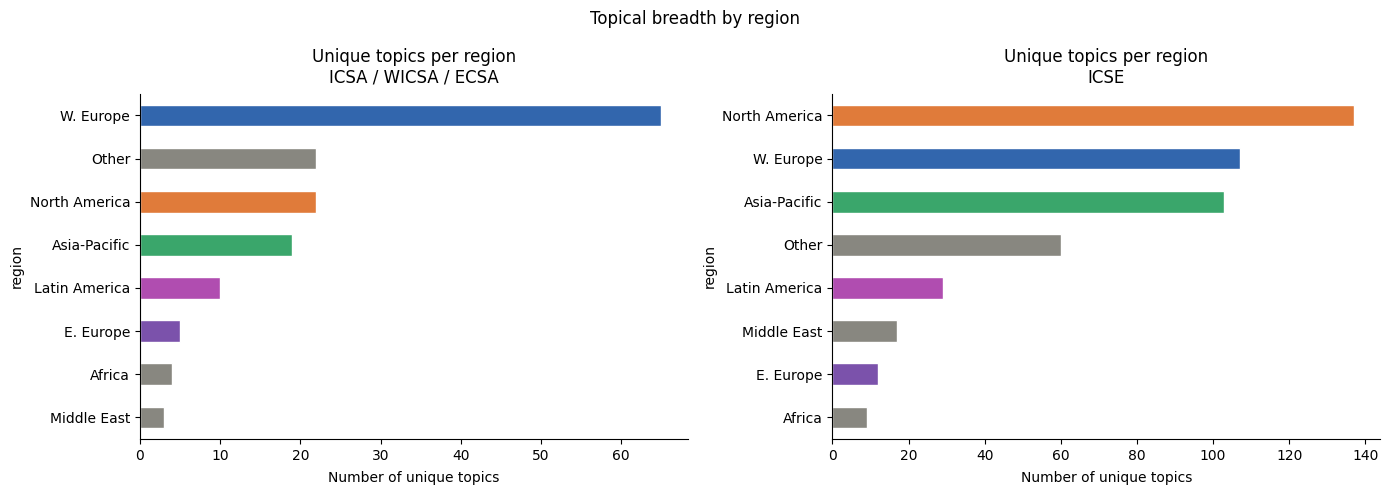

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, dt, label in zip(axes, [dt_icsa, dt_icse], ["ICSA / WICSA / ECSA", "ICSE"]):
    unique_topics = (
        dt.groupby("region")["primary_topic"]
          .nunique()
          .sort_values(ascending=True)
    )
    colors = [REGION_COLORS.get(r, "#888780") for r in unique_topics.index]
    unique_topics.plot(kind="barh", ax=ax, color=colors, edgecolor="white")
    ax.set_xlabel("Number of unique topics", labelpad=6)
    ax.set_title(f"Unique topics per region\n{label}", pad=8)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Topical breadth by region", fontsize=12)
plt.tight_layout()
save_fig(fig, "fig_unique_topics_per_region.png")
plt.show()

Topics Unique to Underrepresented Regions

In [44]:
# topics that appear in Asia-Pacific/Latin America but NOT in W. Europe or North America
dominant_topics = set(dt_icsa[dt_icsa["region"].isin(["W. Europe","North America"])]["primary_topic"])
other_topics    = set(dt_icsa[~dt_icsa["region"].isin(["W. Europe","North America"])]["primary_topic"])
unique_to_others = other_topics - dominant_topics
print("Topics only from non-dominant regions:", unique_to_others)

Topics only from non-dominant regions: {'Cloud Data Security Solutions', 'Distributed and Parallel Computing Systems', 'Electronic Health Records Systems', 'Digital and Cyber Forensics', 'Quantum Computing Algorithms and Architecture', 'Agricultural risk and resilience'}


In [45]:
dt_icsa["decade"] = dt_icsa["year"].apply(lambda y: "2010-2015" if y <= 2015 else "2016-2025")


=== ICSA / WICSA / ECSA ===
  2010–2015 (n=6): Pearson r=0.03 (p=0.960) | Spearman r=-0.03 (p=0.957)
  2016–2025 (n=10): Pearson r=0.05 (p=0.886) | Spearman r=0.12 (p=0.751)
Saved → fig_geo_topic_by_period_icsa.png


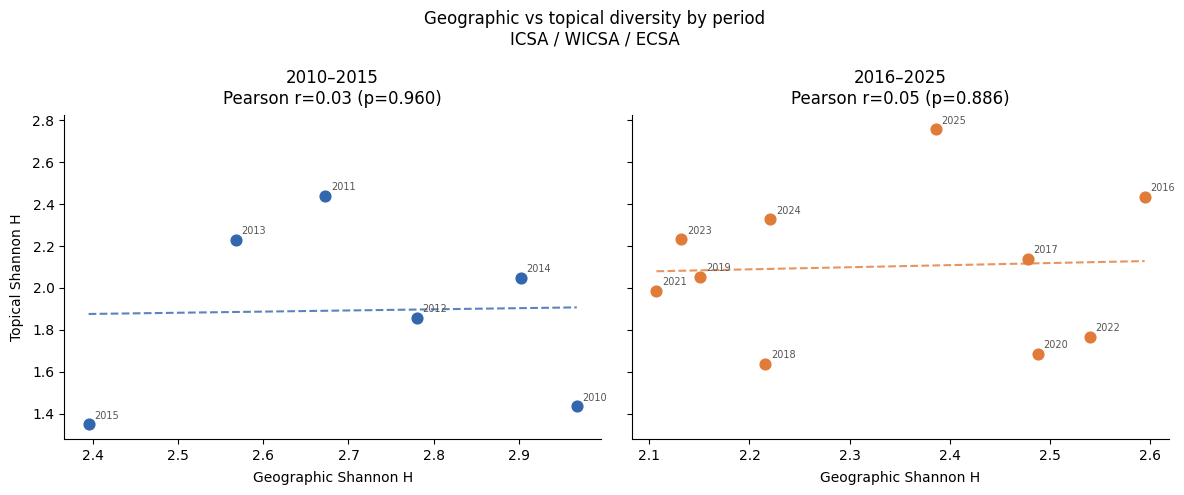


=== ICSE ===
  2010–2015 (n=6): Pearson r=0.84 (p=0.036) | Spearman r=0.66 (p=0.156)
  2016–2025 (n=10): Pearson r=-0.59 (p=0.074) | Spearman r=-0.76 (p=0.011)
Saved → fig_geo_topic_by_period_icse.png


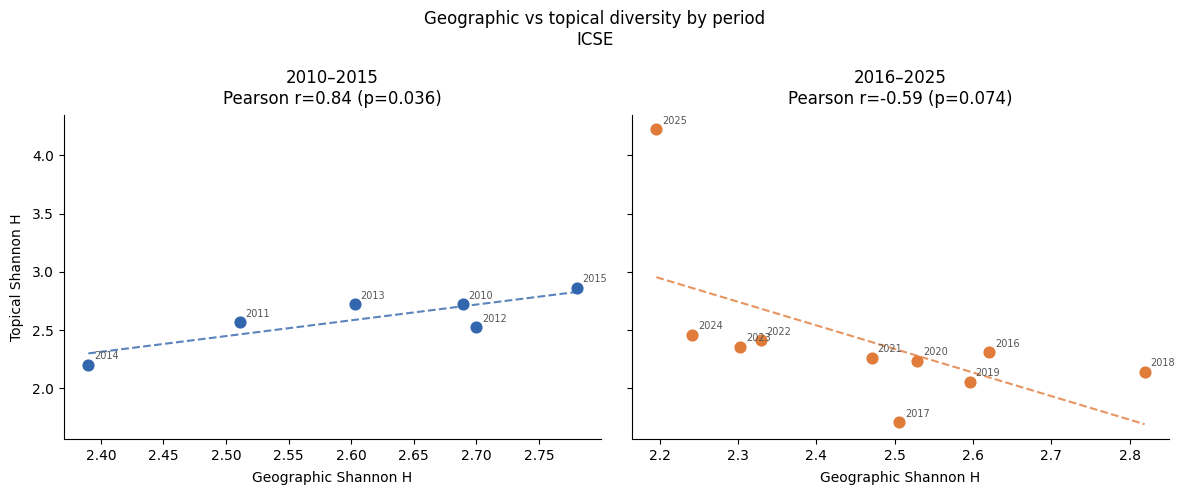

In [46]:
# ── Correlation by time period ─────────────────────────────────────────────────

def geo_topic_correlation_by_period(df_full, dt, label):
    geo   = geo_shannon(df_full)
    topo  = topical_shannon_by_year(dt)
    merged = geo.join(topo, how="inner").reset_index()
    
    merged["period"] = merged["year"].apply(
        lambda y: "2010–2015" if y <= 2015 else "2016–2025"
    )
    
    print(f"\n=== {label} ===")
    for period, group in merged.groupby("period"):
        if len(group) < 3:
            print(f"  {period}: not enough data points")
            continue
        r_p, p_p = pearsonr(group["geo_H"], group["topic_H"])
        r_s, p_s = spearmanr(group["geo_H"], group["topic_H"])
        print(f"  {period} (n={len(group)}): "
              f"Pearson r={r_p:.2f} (p={p_p:.3f}) | "
              f"Spearman r={r_s:.2f} (p={p_s:.3f})")
    
    # plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    colors = {"2010–2015": "#3266ad", "2016–2025": "#e07b3a"}
    
    for ax, (period, group) in zip(axes, merged.groupby("period")):
        ax.scatter(group["geo_H"], group["topic_H"],
                   color=colors[period], s=60, zorder=3)
        for _, row in group.iterrows():
            ax.annotate(str(int(row["year"])),
                        (row["geo_H"], row["topic_H"]),
                        textcoords="offset points", xytext=(4, 4),
                        fontsize=7, color="#555")
        if len(group) >= 3:
            m, b = np.polyfit(group["geo_H"], group["topic_H"], 1)
            x_line = np.linspace(group["geo_H"].min(), group["geo_H"].max(), 100)
            ax.plot(x_line, m * x_line + b, "--",
                    color=colors[period], lw=1.5, alpha=0.8)
            r_p, p_p = pearsonr(group["geo_H"], group["topic_H"])
            ax.set_title(f"{period}\nPearson r={r_p:.2f} (p={p_p:.3f})", pad=8)
        
        ax.set_xlabel("Geographic Shannon H", labelpad=6)
        ax.spines[["top", "right"]].set_visible(False)
    
    axes[0].set_ylabel("Topical Shannon H", labelpad=6)
    fig.suptitle(f"Geographic vs topical diversity by period\n{label}", fontsize=12)
    plt.tight_layout()
    save_fig(fig, f"fig_geo_topic_by_period_{label.split()[0].lower()}.png")
    plt.show()

geo_topic_correlation_by_period(df_icsa, dt_icsa, "ICSA / WICSA / ECSA")
geo_topic_correlation_by_period(df_icse, dt_icse, "ICSE")

Saved → fig_topical_hhi.png


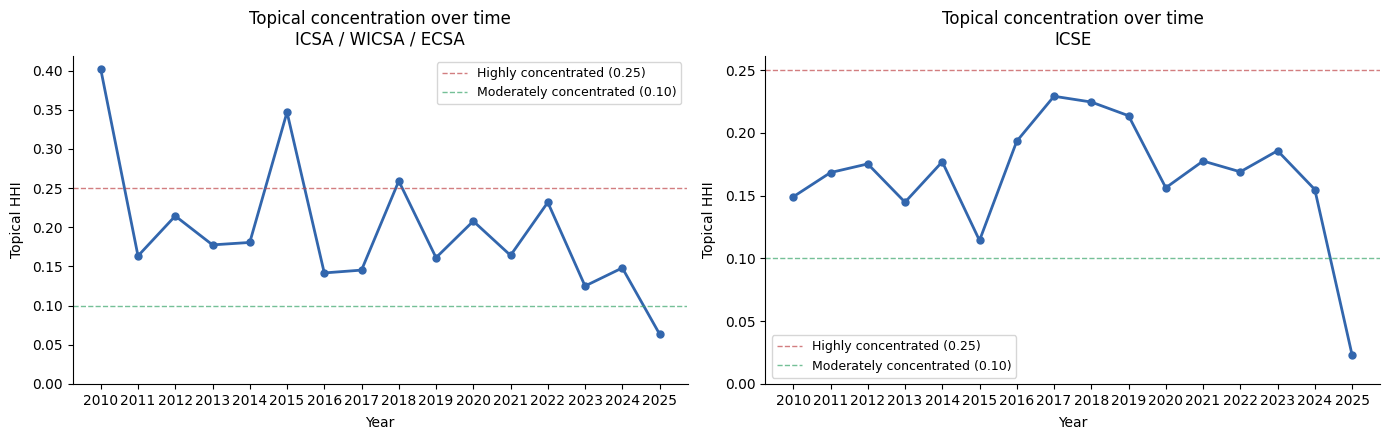

In [47]:
def compute_topical_hhi(dt):
    rows = []
    for year, g in dt.groupby("year"):
        tc = g.drop_duplicates(subset=["doi","primary_topic"]).groupby("primary_topic").size()
        p  = tc / tc.sum()
        rows.append({"year": year, "topical_hhi": round(float((p**2).sum()), 4)})
    return pd.DataFrame(rows).set_index("year")

thhi_icsa = compute_topical_hhi(dt_icsa)
thhi_icse = compute_topical_hhi(dt_icse)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, thhi, label in zip(axes, [thhi_icsa, thhi_icse], ["ICSA / WICSA / ECSA", "ICSE"]):
    ax.plot(thhi.index, thhi["topical_hhi"], "o-", color="#3266ad", lw=2, ms=5)
    ax.axhline(0.25, color="#c0474a", lw=1, linestyle="--", alpha=0.7, label="Highly concentrated (0.25)")
    ax.axhline(0.10, color="#3aa66b", lw=1, linestyle="--", alpha=0.7, label="Moderately concentrated (0.10)")
    ax.set_ylabel("Topical HHI", labelpad=6)
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=9)
    ax.set_title(f"Topical concentration over time\n{label}", pad=8)
    ax.spines[["top","right"]].set_visible(False)
    ax.set_xlabel("Year", labelpad=6)
    ax.set_xticks(thhi.index)

plt.tight_layout()
save_fig(fig, "fig_topical_hhi.png")
plt.show()

Saved → fig_topical_vs_geo_hhi.png


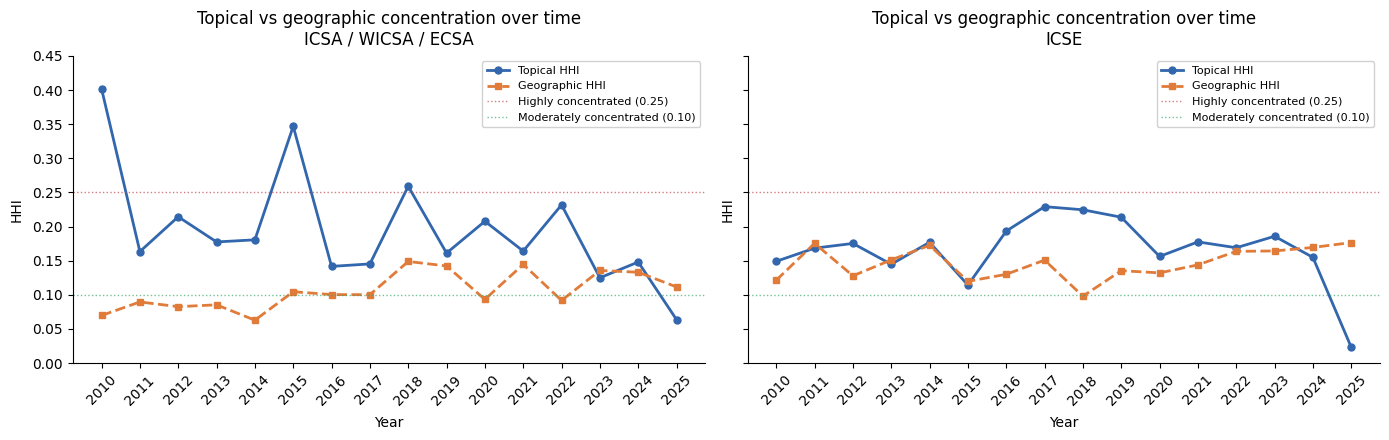

In [48]:
def compute_geo_hhi(df):
    rows = []
    for year, g in df.dropna(subset=["country_code"]).drop_duplicates(
            subset=["doi", "year", "country_code"]).groupby("year"):
        p = g.groupby("country_code")["doi"].nunique()
        p = p / p.sum()
        rows.append({"year": year, "geo_hhi": round(float((p**2).sum()), 4)})
    return pd.DataFrame(rows).set_index("year")

thhi_icsa = compute_topical_hhi(dt_icsa)
thhi_icse = compute_topical_hhi(dt_icse)
ghhi_icsa = compute_geo_hhi(df_icsa)
ghhi_icse = compute_geo_hhi(df_icse)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)

for ax, thhi, ghhi, label in zip(
    axes,
    [thhi_icsa, thhi_icse],
    [ghhi_icsa, ghhi_icse],
    ["ICSA / WICSA / ECSA", "ICSE"]
):
    ax.plot(thhi.index, thhi["topical_hhi"], "o-",
            color="#3266ad", lw=2, ms=5, label="Topical HHI")
    ax.plot(ghhi.index, ghhi["geo_hhi"], "s--",
            color="#e07b3a", lw=2, ms=5, label="Geographic HHI")
    ax.axhline(0.25, color="#c0474a", lw=1, linestyle=":", alpha=0.7,
               label="Highly concentrated (0.25)")
    ax.axhline(0.10, color="#3aa66b", lw=1, linestyle=":", alpha=0.7,
               label="Moderately concentrated (0.10)")
    ax.set_ylabel("HHI", labelpad=6)
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=8, framealpha=0.9)
    ax.set_title(f"Topical vs geographic concentration over time\n{label}", pad=8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xlabel("Year", labelpad=6)
    ax.set_xticks(thhi.index)
    ax.tick_params(axis="x", rotation=45)
    ax.set_ylim(0, 0.45)

plt.tight_layout()
save_fig(fig, "fig_topical_vs_geo_hhi.png")
plt.show()


=== ICSA / WICSA / ECSA ===
  Dominant region topics:          67
  Underrepresented region topics:  35
  Shared topics:                   29
  Unique to dominant regions:      38
  Unique to underrepresented:      6

  Topics ONLY from underrepresented regions:
    - Agricultural risk and resilience: {'Asia-Pacific': 1}
    - Cloud Data Security Solutions: {'Asia-Pacific': 1}
    - Digital and Cyber Forensics: {'Asia-Pacific': 1}
    - Distributed and Parallel Computing Systems: {'Other': 1}
    - Electronic Health Records Systems: {'Other': 1}
    - Quantum Computing Algorithms and Architecture: {'Asia-Pacific': 1}

  Topics ONLY from dominant regions:
    - Advanced Data Storage Technologies: {'W. Europe': 2}
    - Architecture and Computational Design: {'W. Europe': 2}
    - Artificial Intelligence in Games: {'W. Europe': 1}
    - Autonomous Vehicle Technology and Safety: {'W. Europe': 1}
    - Business Process Modeling and Analysis: {'North America': 1, 'W. Europe': 6}
    - Comp

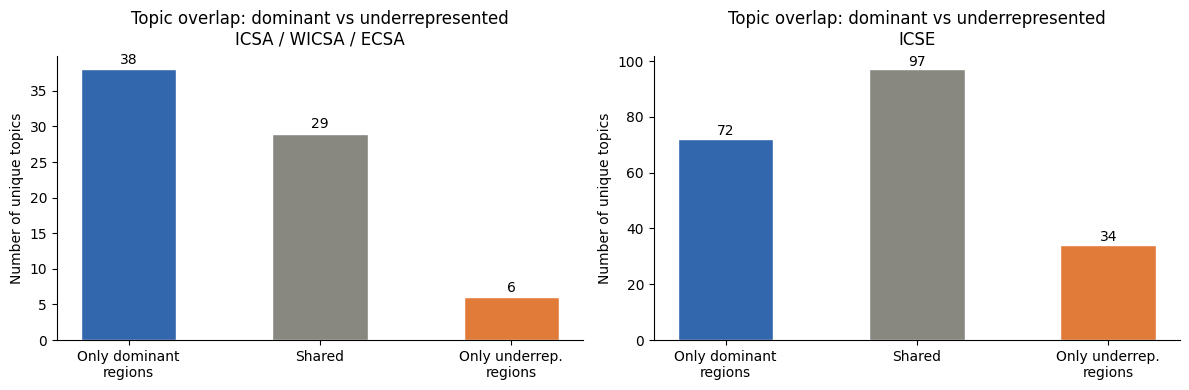


=== Papers behind underrepresented-only topics (ICSA) ===
                                primary_topic       region  n_papers
             Agricultural risk and resilience Asia-Pacific         1
                Cloud Data Security Solutions Asia-Pacific         1
                  Digital and Cyber Forensics Asia-Pacific         1
   Distributed and Parallel Computing Systems        Other         1
            Electronic Health Records Systems        Other         1
Quantum Computing Algorithms and Architecture Asia-Pacific         1

=== Papers behind underrepresented-only topics (ICSE) ===
                                         primary_topic        region  n_papers
              Autonomous Vehicle Technology and Safety  Asia-Pacific         4
                      Video Analysis and Summarization  Asia-Pacific         2
                      Artificial Intelligence in Games  Asia-Pacific         2
                            3D IC and TSV technologies Latin America         1
    

In [49]:
# ── Topics unique to underrepresented regions ──────────────────────────────────

DOMINANT_REGIONS    = ["W. Europe", "North America"]
UNDERREP_REGIONS    = ["Asia-Pacific", "Latin America", "E. Europe",
                       "Middle East & Africa", "Other"]

def topic_overlap_analysis(dt, label):
    dominant_topics = set(
        dt[dt["region"].isin(DOMINANT_REGIONS)]["primary_topic"].unique()
    )
    underrep_topics = set(
        dt[dt["region"].isin(UNDERREP_REGIONS)]["primary_topic"].unique()
    )

    unique_to_dominant   = dominant_topics - underrep_topics
    unique_to_underrep   = underrep_topics - dominant_topics
    shared               = dominant_topics & underrep_topics

    print(f"\n=== {label} ===")
    print(f"  Dominant region topics:          {len(dominant_topics)}")
    print(f"  Underrepresented region topics:  {len(underrep_topics)}")
    print(f"  Shared topics:                   {len(shared)}")
    print(f"  Unique to dominant regions:      {len(unique_to_dominant)}")
    print(f"  Unique to underrepresented:      {len(unique_to_underrep)}")
    print(f"\n  Topics ONLY from underrepresented regions:")
    for t in sorted(unique_to_underrep):
        # show which region and how many papers
        papers = dt[dt["primary_topic"] == t]
        region_counts = papers.groupby("region")["doi"].nunique().to_dict()
        print(f"    - {t}: {region_counts}")

    print(f"\n  Topics ONLY from dominant regions:")
    for t in sorted(unique_to_dominant):
        papers = dt[dt["primary_topic"] == t]
        region_counts = papers.groupby("region")["doi"].nunique().to_dict()
        print(f"    - {t}: {region_counts}")

    return unique_to_dominant, unique_to_underrep, shared

uniq_dom_icsa, uniq_und_icsa, shared_icsa = topic_overlap_analysis(dt_icsa, "ICSA / WICSA / ECSA")
uniq_dom_icse, uniq_und_icse, shared_icse = topic_overlap_analysis(dt_icse, "ICSE")

# ── Venn-style bar chart ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, uniq_dom, uniq_und, shared, label in zip(
    axes,
    [uniq_dom_icsa, uniq_dom_icse],
    [uniq_und_icsa, uniq_und_icse],
    [shared_icsa,   shared_icse],
    ["ICSA / WICSA / ECSA", "ICSE"]
):
    categories = ["Only dominant\nregions", "Shared", "Only underrep.\nregions"]
    values     = [len(uniq_dom), len(shared), len(uniq_und)]
    colors     = ["#3266ad", "#888780", "#e07b3a"]
    bars = ax.bar(categories, values, color=colors, edgecolor="white", width=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.3,
                str(val), ha="center", va="bottom", fontsize=10)
    ax.set_ylabel("Number of unique topics")
    ax.set_title(f"Topic overlap: dominant vs underrepresented\n{label}", pad=8)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
save_fig(fig, "fig_topic_overlap.png")
plt.show()

# ── Show underrep-only topics with paper counts ────────────────────────────────
print("\n=== Papers behind underrepresented-only topics (ICSA) ===")
if uniq_und_icsa:
    df_uniq = (
        dt_icsa[dt_icsa["primary_topic"].isin(uniq_und_icsa)]
        .drop_duplicates(subset=["doi","primary_topic"])
        .groupby(["primary_topic","region"])["doi"]
        .nunique()
        .reset_index()
        .rename(columns={"doi": "n_papers"})
        .sort_values("n_papers", ascending=False)
    )
    print(df_uniq.to_string(index=False))

print("\n=== Papers behind underrepresented-only topics (ICSE) ===")
if uniq_und_icse:
    df_uniq = (
        dt_icse[dt_icse["primary_topic"].isin(uniq_und_icse)]
        .drop_duplicates(subset=["doi","primary_topic"])
        .groupby(["primary_topic","region"])["doi"]
        .nunique()
        .reset_index()
        .rename(columns={"doi": "n_papers"})
        .sort_values("n_papers", ascending=False)
    )
    print(df_uniq.to_string(index=False))

# ── How many papers are behind each underrep-only topic? ──────────────────────
# flag: are these meaningful contributions or just 1-2 papers?
print("\n=== Underrep-only topic paper counts (ICSA) ===")
for topic in sorted(uniq_und_icsa):
    n = dt_icsa[dt_icsa["primary_topic"] == topic]["doi"].nunique()
    flag = "⚠ small sample" if n <= 2 else ""
    print(f"  {topic}: {n} papers {flag}")

print("\n=== Underrep-only topic paper counts (ICSE) ===")
for topic in sorted(uniq_und_icse):
    n = dt_icse[dt_icse["primary_topic"] == topic]["doi"].nunique()
    flag = "⚠ small sample" if n <= 2 else ""
    print(f"  {topic}: {n} papers {flag}")
    

In [50]:
# ── Option 3: per-region topic specialization ──────────────────────────────────
# For each region, what are its most distinctive topics relative to the overall distribution?

def topic_specialization(dt, label, top_n=5):
    """
    Computes a specialization score for each region-topic pair.
    Score = region's % share of topic / region's overall % share of all papers
    Score > 1 means the region is over-represented in that topic relative to its size.
    """
    # overall share of each region
    region_share = (
        dt.groupby("region")["doi"].nunique() /
        dt["doi"].nunique()
    )

    # share of each topic that comes from each region
    topic_region = (
        dt.groupby(["primary_topic", "region"])["doi"].nunique()
        .unstack(fill_value=0)
    )
    topic_region_pct = topic_region.div(topic_region.sum(axis=1), axis=0)

    # specialization = topic share / overall share
    specialization = topic_region_pct.div(region_share, axis=1)

    print(f"\n=== {label} — Top {top_n} most distinctive topics per region ===")
    for region in specialization.columns:
        top = (
            specialization[region]
            .sort_values(ascending=False)
            .head(top_n)
        )
        # filter out topics with very few papers
        top = top[top.index.map(
            lambda t: dt[dt["primary_topic"]==t]["doi"].nunique() >= 3
        )]
        print(f"\n  {region}:")
        for topic, score in top.items():
            n = dt[dt["primary_topic"]==topic]["doi"].nunique()
            print(f"    {topic} (score={score:.1f}, n={n} papers)")

    return specialization

spec_icsa = topic_specialization(dt_icsa, "ICSA / WICSA / ECSA")
spec_icse = topic_specialization(dt_icse, "ICSE")


=== ICSA / WICSA / ECSA — Top 5 most distinctive topics per region ===

  Africa:
    Service-Oriented Architecture and Web Services (score=4.5, n=26 papers)
    Advanced Software Engineering Methodologies (score=1.6, n=129 papers)
    Software System Performance and Reliability (score=0.6, n=64 papers)
    Software Engineering Research (score=0.4, n=87 papers)

  Asia-Pacific:
    Blockchain Technology Applications and Security (score=4.4, n=7 papers)

  E. Europe:
    Software Reliability and Analysis Research (score=4.9, n=5 papers)
    Cloud Computing and Resource Management (score=3.8, n=9 papers)
    Software System Performance and Reliability (score=1.7, n=64 papers)
    Advanced Software Engineering Methodologies (score=1.6, n=129 papers)
    Software Engineering Research (score=0.3, n=87 papers)

  Latin America:
    Advanced Malware Detection Techniques (score=4.4, n=4 papers)
    Scientific Computing and Data Management (score=3.6, n=4 papers)
    Semantic Web and Ontologie

In [51]:
from scipy.stats import chi2_contingency

def chi_square_region_topic(mat, label, min_papers=3):
    # filter to topics with enough papers
    mat_filtered = mat.loc[:, mat.sum() >= min_papers]
    # filter to regions with enough papers  
    mat_filtered = mat_filtered.loc[mat_filtered.sum(axis=1) >= min_papers]
    
    chi2, p, dof, expected = chi2_contingency(mat_filtered)
    print(f"\n{label}")
    print(f"  Chi-square = {chi2:.2f}, df = {dof}, p = {p:.4f}")
    print(f"  Regions included: {list(mat_filtered.index)}")
    print(f"  Topics included:  {mat_filtered.shape[1]}")
    if p < 0.05:
        print("  ✓ Topic distribution differs significantly across regions")
    else:
        print("  ✗ No significant difference in topic distribution across regions")

chi_square_region_topic(mat_icsa, "ICSA / WICSA / ECSA")
chi_square_region_topic(mat_icse, "ICSE")


ICSA / WICSA / ECSA
  Chi-square = 211.78, df = 182, p = 0.0645
  Regions included: ['Africa', 'Asia-Pacific', 'E. Europe', 'Latin America', 'Middle East', 'North America', 'Other', 'W. Europe']
  Topics included:  27
  ✗ No significant difference in topic distribution across regions

ICSE
  Chi-square = 818.19, df = 581, p = 0.0000
  Regions included: ['Africa', 'Asia-Pacific', 'E. Europe', 'Latin America', 'Middle East', 'North America', 'Other', 'W. Europe']
  Topics included:  84
  ✓ Topic distribution differs significantly across regions



ICSA / WICSA / ECSA — Jaccard similarity between regions:
               Africa  Asia-Pacific  E. Europe  Latin America  Middle East  North America  Other  W. Europe
Africa           1.00          0.21       0.50           0.40         0.40           0.18   0.18       0.06
Asia-Pacific     0.21          1.00       0.20           0.26         0.10           0.28   0.32       0.20
E. Europe        0.50          0.20       1.00           0.36         0.33           0.23   0.17       0.08
Latin America    0.40          0.26       0.36           1.00         0.18           0.28   0.23       0.15
Middle East      0.40          0.10       0.33           0.18         1.00           0.14   0.09       0.05
North America    0.18          0.28       0.23           0.28         0.14           1.00   0.33       0.30
Other            0.18          0.32       0.17           0.23         0.09           0.33   1.00       0.28
W. Europe        0.06          0.20       0.08           0.15         0.05   

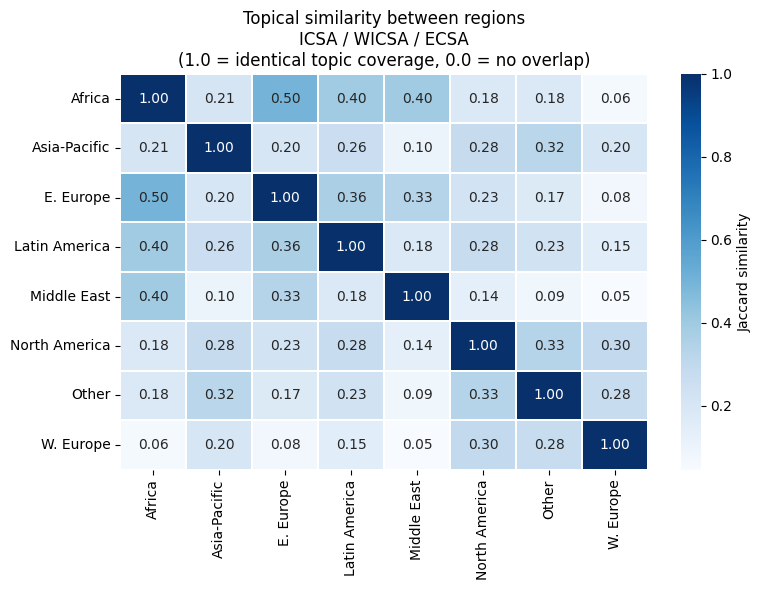


ICSE — Jaccard similarity between regions:
               Africa  Asia-Pacific  E. Europe  Latin America  Middle East  North America  Other  W. Europe
Africa           1.00          0.08       0.24           0.19         0.18           0.06   0.13       0.08
Asia-Pacific     0.08          1.00       0.08           0.15         0.13           0.35   0.37       0.47
E. Europe        0.24          0.08       1.00           0.21         0.32           0.08   0.11       0.10
Latin America    0.19          0.15       0.21           1.00         0.24           0.15   0.22       0.20
Middle East      0.18          0.13       0.32           0.24         1.00           0.12   0.17       0.16
North America    0.06          0.35       0.08           0.15         0.12           1.00   0.31       0.44
Other            0.13          0.37       0.11           0.22         0.17           0.31   1.00       0.33
W. Europe        0.08          0.47       0.10           0.20         0.16           0.44   

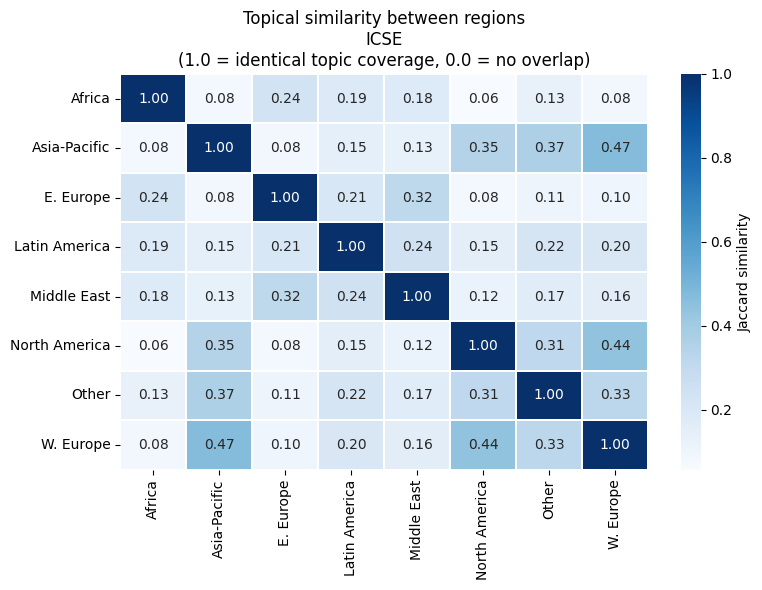

In [52]:
def jaccard_similarity_matrix(mat, label, min_papers=3):
    mat_bin = (mat >= 1).astype(int)  # presence/absence
    regions = mat_bin.index.tolist()
    
    sim_matrix = pd.DataFrame(index=regions, columns=regions, dtype=float)
    for r1 in regions:
        for r2 in regions:
            intersection = (mat_bin.loc[r1] & mat_bin.loc[r2]).sum()
            union = (mat_bin.loc[r1] | mat_bin.loc[r2]).sum()
            sim_matrix.loc[r1, r2] = intersection / union if union > 0 else 0
    
    print(f"\n{label} — Jaccard similarity between regions:")
    print(sim_matrix.round(2).to_string())
    
    # heatmap
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(sim_matrix.astype(float), ax=ax, cmap="Blues",
                annot=True, fmt=".2f", linewidths=0.3,
                cbar_kws={"label": "Jaccard similarity"})
    ax.set_title(f"Topical similarity between regions\n{label}\n"
                 f"(1.0 = identical topic coverage, 0.0 = no overlap)")
    plt.tight_layout()
    save_fig(fig, f"fig_jaccard_{label.split()[0].lower()}.png")
    plt.show()

jaccard_similarity_matrix(mat_icsa, "ICSA / WICSA / ECSA")
jaccard_similarity_matrix(mat_icse, "ICSE")

Saved → fig_china_flip_combined.png


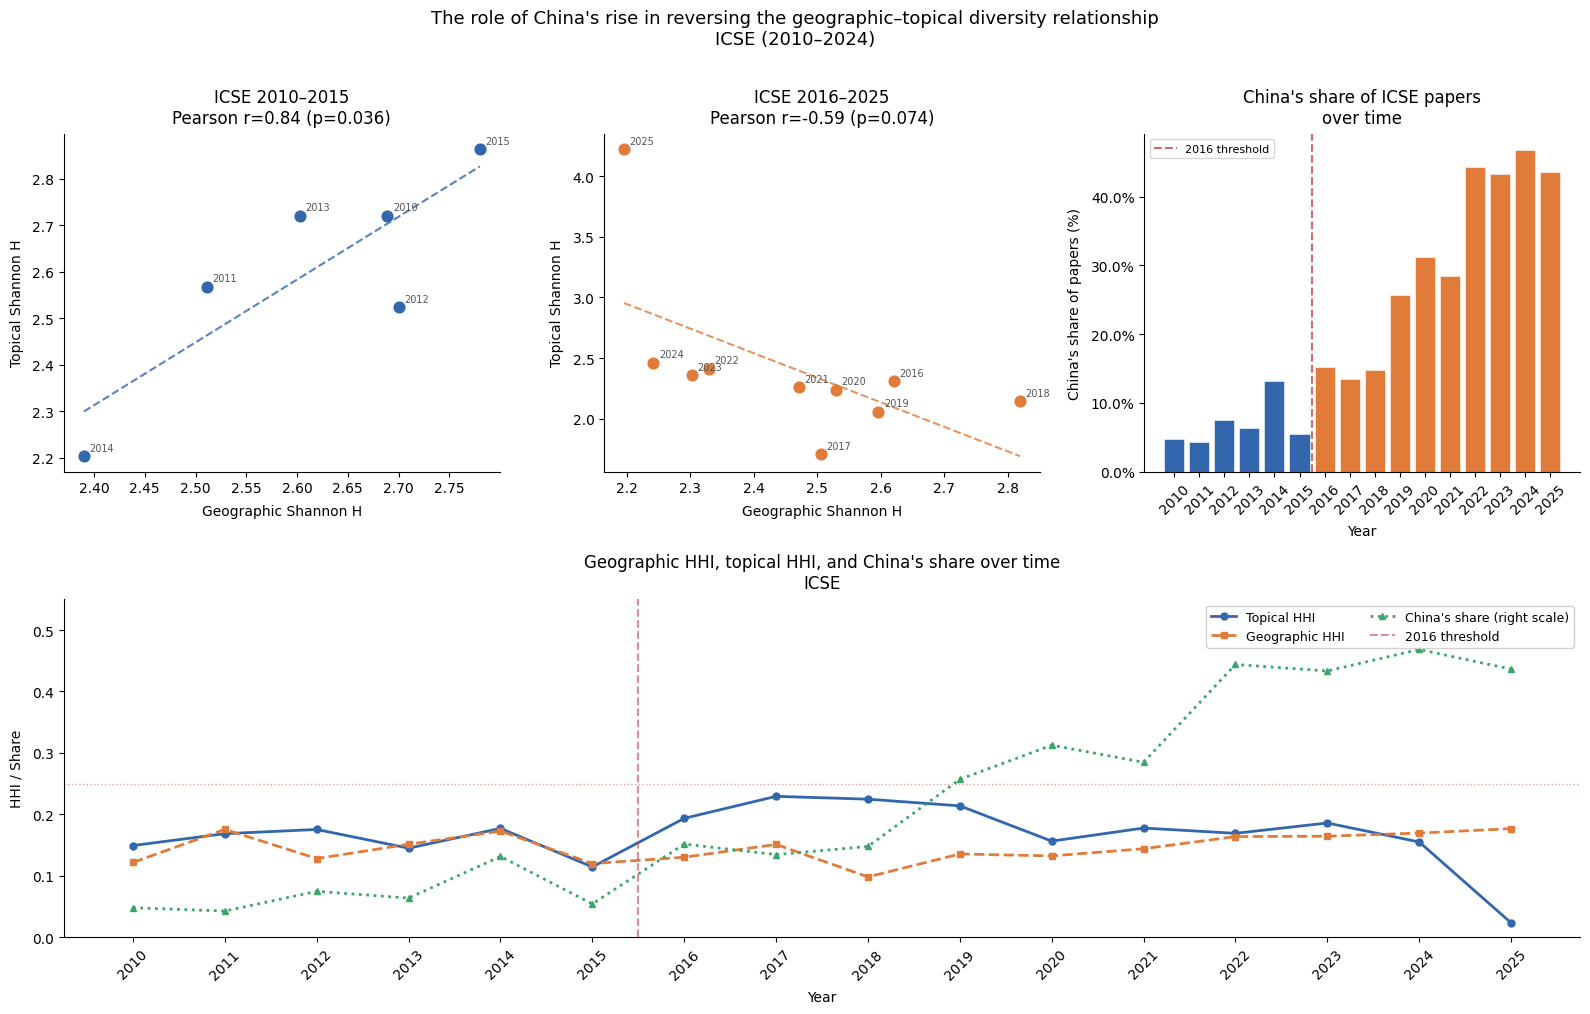

In [53]:
# ── Combined figure: ICSE geographic-topical flip + China's rise ───────────────

fig = plt.figure(figsize=(16, 10))

# ── Top row: period correlation plots ─────────────────────────────────────────
geo   = geo_shannon(df_icse)
topo  = topical_shannon_by_year(dt_icse)
merged = geo.join(topo, how="inner").reset_index()
merged["period"] = merged["year"].apply(
    lambda y: "2010–2015" if y <= 2015 else "2016–2025"
)

period_colors = {"2010–2015": "#3266ad", "2016–2025": "#e07b3a"}

for i, (period, group) in enumerate(merged.groupby("period")):
    ax = fig.add_subplot(2, 3, i + 1)
    ax.scatter(group["geo_H"], group["topic_H"],
               color=period_colors[period], s=60, zorder=3)
    for _, row in group.iterrows():
        ax.annotate(str(int(row["year"])),
                    (row["geo_H"], row["topic_H"]),
                    textcoords="offset points", xytext=(4, 4),
                    fontsize=7, color="#555")
    if len(group) >= 3:
        m, b = np.polyfit(group["geo_H"], group["topic_H"], 1)
        x_line = np.linspace(group["geo_H"].min(), group["geo_H"].max(), 100)
        ax.plot(x_line, m * x_line + b, "--",
                color=period_colors[period], lw=1.5, alpha=0.8)
        r_p, p_p = pearsonr(group["geo_H"], group["topic_H"])
        ax.set_title(f"ICSE {period}\nPearson r={r_p:.2f} (p={p_p:.3f})", pad=8)
    ax.set_xlabel("Geographic Shannon H", labelpad=6)
    ax.set_ylabel("Topical Shannon H", labelpad=6)
    ax.spines[["top", "right"]].set_visible(False)

# ── Top right: China's share over time ────────────────────────────────────────
ax3 = fig.add_subplot(2, 3, 3)

year_totals = (
    df_icse.dropna(subset=["country_code"])
    .drop_duplicates(subset=["doi", "year", "country_code"])
    .drop_duplicates(subset=["doi", "year"])
    .groupby("year")["doi"].nunique()
)
china_papers = (
    df_icse[df_icse["country_code"] == "CN"]
    .drop_duplicates(subset=["doi", "year"])
    .groupby("year")["doi"].nunique()
)
china_pct = (china_papers / year_totals * 100).fillna(0)

ax3.bar(china_pct.index, china_pct.values,
        color=["#e07b3a" if y >= 2016 else "#3266ad" for y in china_pct.index],
        edgecolor="white", linewidth=0.4)
ax3.axvline(2015.5, color="#c0474a", lw=1.5, linestyle="--", alpha=0.8,
            label="2016 threshold")
ax3.set_xlabel("Year", labelpad=6)
ax3.set_ylabel("China's share of papers (%)", labelpad=6)
ax3.yaxis.set_major_formatter(mtick.PercentFormatter())
ax3.set_title("China's share of ICSE papers\nover time", pad=8)
ax3.set_xticks(china_pct.index)
ax3.tick_params(axis="x", rotation=45)
ax3.legend(fontsize=8)
ax3.spines[["top", "right"]].set_visible(False)

# ── Bottom row: HHI geographic vs topical ─────────────────────────────────────
ax4 = fig.add_subplot(2, 1, 2)

thhi = compute_topical_hhi(dt_icse)
ghhi = compute_geo_hhi(df_icse)

ax4.plot(thhi.index, thhi["topical_hhi"], "o-",
         color="#3266ad", lw=2, ms=5, label="Topical HHI")
ax4.plot(ghhi.index, ghhi["geo_hhi"], "s--",
         color="#e07b3a", lw=2, ms=5, label="Geographic HHI")
ax4.plot(china_pct.index, china_pct.values / 100, "^:",
         color="#3aa66b", lw=2, ms=5, label="China's share (right scale)")
ax4.axvline(2015.5, color="#c0474a", lw=1.5, linestyle="--", alpha=0.6,
            label="2016 threshold")
ax4.axhline(0.25, color="#c0474a", lw=1, linestyle=":", alpha=0.5)
ax4.set_xlabel("Year", labelpad=6)
ax4.set_ylabel("HHI / Share", labelpad=6)
ax4.set_xticks(sorted(df_icse["year"].unique()))
ax4.tick_params(axis="x", rotation=45)
ax4.set_ylim(0, 0.55)
ax4.legend(fontsize=9, framealpha=0.9, ncol=2)
ax4.set_title("Geographic HHI, topical HHI, and China's share over time\nICSE",
              pad=8)
ax4.spines[["top", "right"]].set_visible(False)

fig.suptitle("The role of China's rise in reversing the geographic–topical diversity relationship\nICSE (2010–2024)",
             fontsize=13, y=1.01)
plt.tight_layout()
save_fig(fig, "fig_china_flip_combined.png")
plt.show()

In [54]:
china_df = pd.DataFrame({
    "china_pct": china_pct,
    "topical_hhi": thhi["topical_hhi"],
    "geo_hhi": ghhi["geo_hhi"]
}).dropna()

r_ct, p_ct = pearsonr(china_df["china_pct"], china_df["topical_hhi"])
r_cg, p_cg = pearsonr(china_df["china_pct"], china_df["geo_hhi"])

print(f"China share vs topical HHI:    r={r_ct:.2f}, p={p_ct:.3f}")
print(f"China share vs geographic HHI: r={r_cg:.2f}, p={p_cg:.3f}")

China share vs topical HHI:    r=-0.23, p=0.390
China share vs geographic HHI: r=0.46, p=0.076



=== ICSA / WICSA / ECSA ===
  2010–2015 (n=6): Spearman r=-0.03 (p=0.957)
  2016–2025 (n=10): Spearman r=0.12 (p=0.751)
Saved → fig_geo_topic_by_period_icsa.png


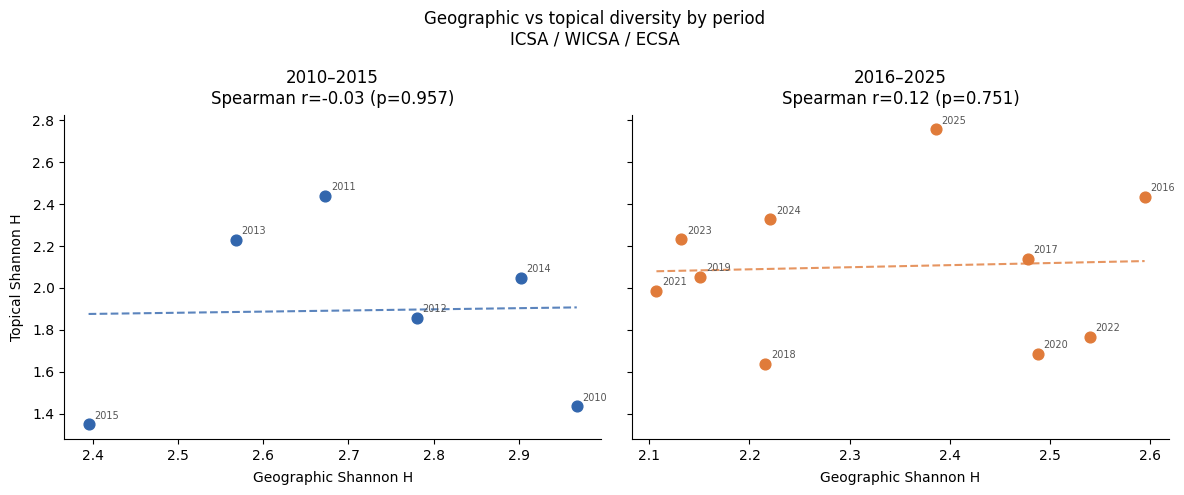


=== ICSE ===
  2010–2015 (n=6): Spearman r=0.66 (p=0.156)
  2016–2025 (n=10): Spearman r=-0.76 (p=0.011)
Saved → fig_geo_topic_by_period_icse.png


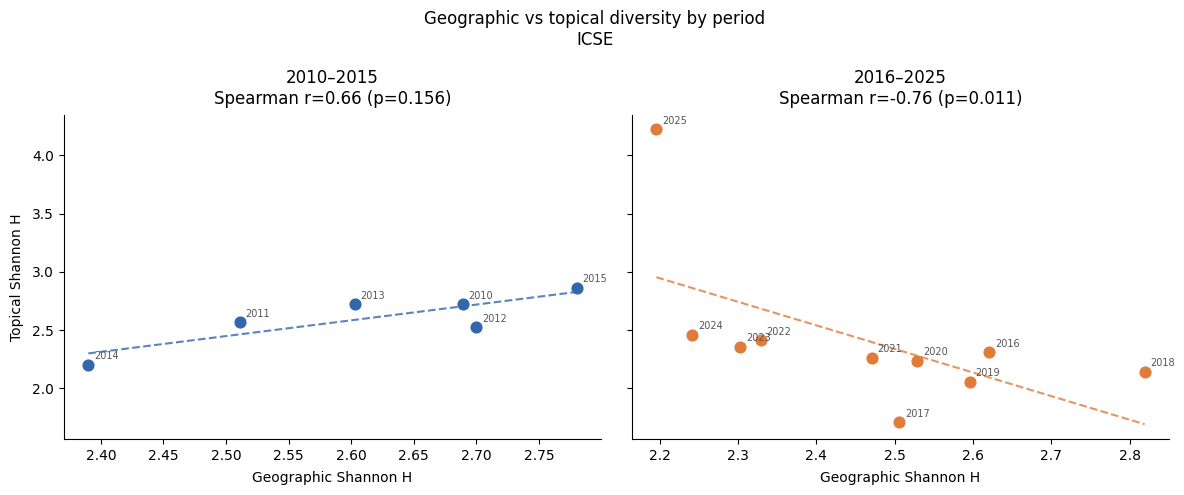

In [55]:
def geo_topic_correlation_by_period(df_full, dt, label):
    from scipy.stats import spearmanr
    
    geo   = geo_shannon(df_full)
    topo  = topical_shannon_by_year(dt)
    merged = geo.join(topo, how="inner").reset_index()
    
    merged["period"] = merged["year"].apply(
        lambda y: "2010–2015" if y <= 2015 else "2016–2025"
    )
    
    print(f"\n=== {label} ===")
    for period, group in merged.groupby("period"):
        if len(group) < 3:
            print(f"  {period}: not enough data points")
            continue
        r_s, p_s = spearmanr(group["geo_H"], group["topic_H"])
        print(f"  {period} (n={len(group)}): Spearman r={r_s:.2f} (p={p_s:.3f})")
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    colors = {"2010–2015": "#3266ad", "2016–2025": "#e07b3a"}
    
    for ax, (period, group) in zip(axes, merged.groupby("period")):
        ax.scatter(group["geo_H"], group["topic_H"],
                   color=colors[period], s=60, zorder=3)
        for _, row in group.iterrows():
            ax.annotate(str(int(row["year"])),
                        (row["geo_H"], row["topic_H"]),
                        textcoords="offset points", xytext=(4, 4),
                        fontsize=7, color="#555")
        if len(group) >= 3:
            m, b = np.polyfit(group["geo_H"], group["topic_H"], 1)
            x_line = np.linspace(group["geo_H"].min(), group["geo_H"].max(), 100)
            ax.plot(x_line, m * x_line + b, "--",
                    color=colors[period], lw=1.5, alpha=0.8)
            r_s, p_s = spearmanr(group["geo_H"], group["topic_H"])
            ax.set_title(f"{period}\nSpearman r={r_s:.2f} (p={p_s:.3f})", pad=8)
        
        ax.set_xlabel("Geographic Shannon H", labelpad=6)
        ax.spines[["top", "right"]].set_visible(False)
    
    axes[0].set_ylabel("Topical Shannon H", labelpad=6)
    fig.suptitle(f"Geographic vs topical diversity by period\n{label}", fontsize=12)
    plt.tight_layout()
    save_fig(fig, f"fig_geo_topic_by_period_{label.split()[0].lower()}.png")
    plt.show()

geo_topic_correlation_by_period(df_icsa, dt_icsa, "ICSA / WICSA / ECSA")
geo_topic_correlation_by_period(df_icse, dt_icse, "ICSE")

Saved → fig_topic_emergence_icsa.png


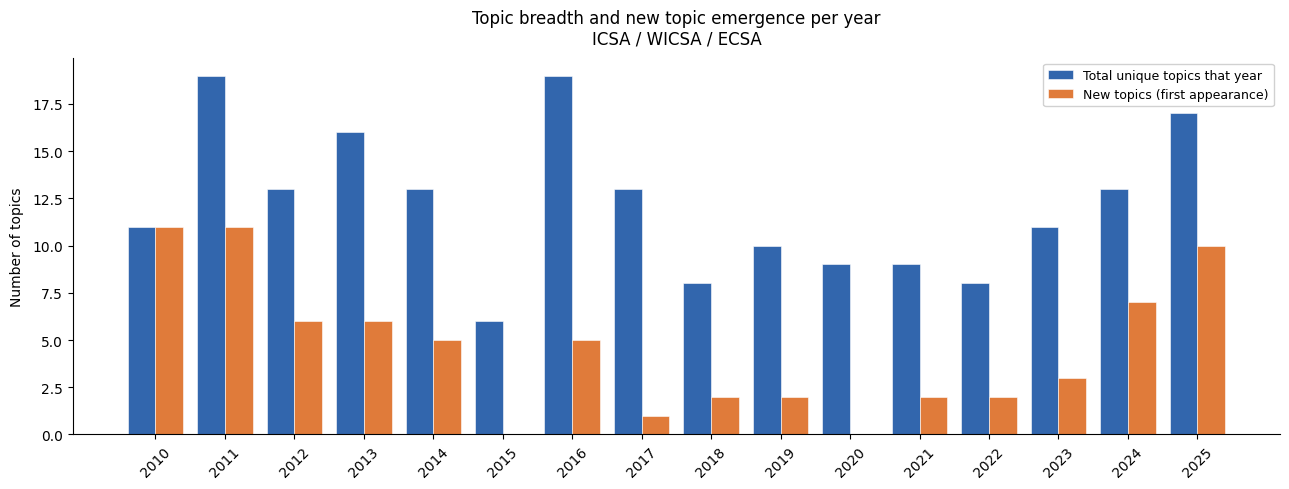

Saved → fig_topic_emergence_icse.png


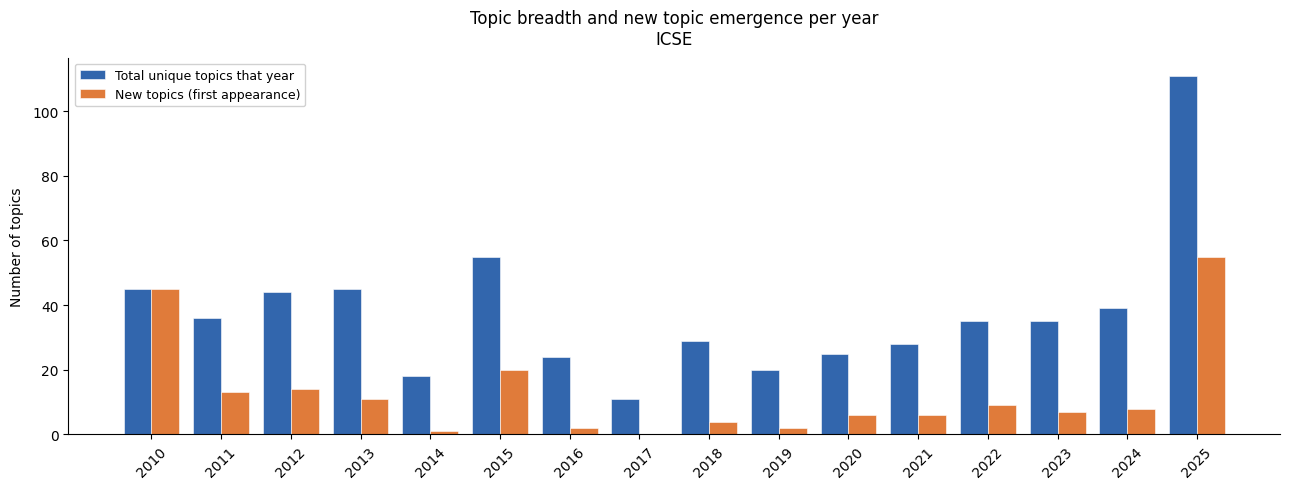

In [56]:
def plot_topic_emergence(dt, label, filename):
    # number of unique topics per year
    topics_per_year = (
        dt.groupby("year")["primary_topic"].nunique()
        .reset_index()
        .rename(columns={"primary_topic": "n_topics"})
    )

    # first appearance year per topic
    first_year = (
        dt.groupby("primary_topic")["year"].min()
        .reset_index()
        .rename(columns={"year": "first_year"})
    )
    new_topics_per_year = (
        first_year.groupby("first_year").size()
        .reset_index()
        .rename(columns={"first_year": "year", 0: "n_new_topics"})
    )

    merged = topics_per_year.merge(new_topics_per_year, on="year", how="left")
    merged["n_new_topics"] = merged["n_new_topics"].fillna(0).astype(int)

    years = merged["year"].tolist()
    x = np.arange(len(years))
    width = 0.4

    fig, ax = plt.subplots(figsize=(13, 5))
    bars1 = ax.bar(x - width/2, merged["n_topics"], width,
                   color="#3266ad", edgecolor="white", linewidth=0.4,
                   label="Total unique topics that year")
    bars2 = ax.bar(x + width/2, merged["n_new_topics"], width,
                   color="#e07b3a", edgecolor="white", linewidth=0.4,
                   label="New topics (first appearance)")

    ax.set_xticks(x)
    ax.set_xticklabels(years, rotation=45)
    ax.set_ylabel("Number of topics", labelpad=6)
    ax.set_title(f"Topic breadth and new topic emergence per year\n{label}", pad=10)
    ax.legend(fontsize=9, framealpha=0.9)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    save_fig(fig, filename)
    plt.show()

plot_topic_emergence(dt_icsa, "ICSA / WICSA / ECSA", "fig_topic_emergence_icsa.png")
plot_topic_emergence(dt_icse, "ICSE", "fig_topic_emergence_icse.png")

In [57]:
from scipy.stats import spearmanr

def geo_topic_no_outlier(df_full, dt, label):
    geo   = geo_shannon(df_full)
    topo  = topical_shannon_by_year(dt)
    merged = geo.join(topo, how="inner").reset_index()
    
    post = merged[merged["year"] >= 2016]
    post_no2025 = post[post["year"] != 2025]
    
    r_all, p_all     = spearmanr(post["geo_H"], post["topic_H"])
    r_no25, p_no25   = spearmanr(post_no2025["geo_H"], post_no2025["topic_H"])
    
    print(f"{label} — post-2016 with 2025:    r={r_all:.2f}, p={p_all:.3f}")
    print(f"{label} — post-2016 without 2025: r={r_no25:.2f}, p={p_no25:.3f}")

geo_topic_no_outlier(df_icse, dt_icse, "ICSE")

ICSE — post-2016 with 2025:    r=-0.76, p=0.011
ICSE — post-2016 without 2025: r=-0.67, p=0.050
